# DarkNav - Data Exploration

**Author:** Miriam Garcia Sollo  
**Date:** June 2026

## Objectives

1. Load the DeepMoon dataset (Silburt et al. 2019, Zenodo 1133969)
2. Understand the real HDF5 structure: input_images and target_masks in the same file
3. Load crater annotations from train_craters.hdf5
4. Visualise a representative sample of real lunar DEM patches with masks
5. Compare real DEM craters side-by-side with NFW synthetic craters
6. Calibrate the mask threshold for the synthetic generator
7. Document statistics and decisions for Day 3

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom, label as scipy_label
from scipy.interpolate import interp1d

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

DATA_DIR = Path('../data')
DOCS_DIR = Path('../docs')
PATCH_SIZE = 128

print('Libraries loaded')
print('Files in data/:', sorted([f.name for f in DATA_DIR.iterdir()]))

Libraries loaded
Files in data/: ['.gitkeep', 'LunarLROLrocKaguya_118mperpix.png', 'dev_craters.hdf5', 'dev_images.hdf5', 'model_keras1.2.2.h5', 'model_keras2.h5', 'post-processed_sample_images.zip', 'post-processed_test_craters.npy', 'test_craters.hdf5', 'test_images.hdf5', 'train_craters.hdf5', 'train_images.hdf5']


## 1. Inspect the HDF5 structure

The DeepMoon Zenodo package stores everything in HDF5 files.
The images HDF5 contains both the DEM patches (input_images) and
the target masks (target_masks) under the same file.
The craters HDF5 stores the crater catalogue separately.

In [2]:
def inspect_hdf5_compact(path):
    """Print only a useful summary of an HDF5 file."""
    print(f'File: {path.name}')
    with h5py.File(path, 'r') as f:
        keys = list(f.keys())
        print(f'  Total keys: {len(keys)}')
        print(f'  First 3 keys: {keys[:3]}')
        # Show structure of first key only
        obj = f[keys[0]]
        if hasattr(obj, 'shape'):
            print(f'  [{keys[0]}] shape={obj.shape} dtype={obj.dtype}')
        else:
            subkeys = list(obj.keys())
            print(f'  [{keys[0]}] GROUP with subkeys: {subkeys}')
            for sk in subkeys:
                sub = obj[sk]
                if hasattr(sub, 'shape'):
                    print(f'    [{sk}] shape={sub.shape} dtype={sub.dtype}')
    print()

for name in ['train_images.hdf5', 'train_craters.hdf5',
             'dev_images.hdf5',   'dev_craters.hdf5',
             'test_images.hdf5',  'test_craters.hdf5']:
    p = DATA_DIR / name
    if not p.exists():
        print(f'MISSING: {name}')
        continue
    with h5py.File(p, 'r') as f:
        keys = list(f.keys())
        obj  = f[keys[0]]
        kind = f'shape={obj.shape} dtype={obj.dtype}' if hasattr(obj, 'shape') \
               else f'GROUP subkeys={list(obj.keys())}'
        print(f'{name}: {len(keys)} keys | first key [{keys[0]}] {kind}')

train_images.hdf5: 6 keys | first key [cll_xy] GROUP subkeys=['img_00000', 'img_00001', 'img_00002', 'img_00003', 'img_00004', 'img_00005', 'img_00006', 'img_00007', 'img_00008', 'img_00009', 'img_00010', 'img_00011', 'img_00012', 'img_00013', 'img_00014', 'img_00015', 'img_00016', 'img_00017', 'img_00018', 'img_00019', 'img_00020', 'img_00021', 'img_00022', 'img_00023', 'img_00024', 'img_00025', 'img_00026', 'img_00027', 'img_00028', 'img_00029', 'img_00030', 'img_00031', 'img_00032', 'img_00033', 'img_00034', 'img_00035', 'img_00036', 'img_00037', 'img_00038', 'img_00039', 'img_00040', 'img_00041', 'img_00042', 'img_00043', 'img_00044', 'img_00045', 'img_00046', 'img_00047', 'img_00048', 'img_00049', 'img_00050', 'img_00051', 'img_00052', 'img_00053', 'img_00054', 'img_00055', 'img_00056', 'img_00057', 'img_00058', 'img_00059', 'img_00060', 'img_00061', 'img_00062', 'img_00063', 'img_00064', 'img_00065', 'img_00066', 'img_00067', 'img_00068', 'img_00069', 'img_00070', 'img_00071', 'i

## 2. Load the dataset

Both input DEM patches and target masks live inside the images HDF5.
The craters HDF5 stores the catalogue for each patch.
We downsample from 256x256 to 128x128 to fit in memory and reduce training time.

In [3]:
def load_crater_group(split, patch_idx, data_dir=DATA_DIR):
    """Load crater DataFrame for one patch from the craters HDF5."""
    crt_path = data_dir / f'{split}_craters.hdf5'
    key = f'img_{patch_idx:05d}'
    with h5py.File(crt_path, 'r') as f:
        if key not in f:
            return None
        grp = f[key]
        # Reconstruct DataFrame from HDF5 group (pandas HDFStore format)
        cols = [c.decode() if isinstance(c, bytes) else c
                for c in grp['block0_items'][()]]
        values = grp['block0_values'][()]  # shape (n_craters, n_cols)
        import pandas as pd
        return pd.DataFrame(values, columns=cols)

# Test
df = load_crater_group('train', 1)
print(df)
print(df.columns.tolist())

     Diameter (km)        Lat        Long           x           y  \
0        14.372061   8.293652 -155.926564   11.810530  253.690977   
1        10.046099   8.317680 -150.092753  125.877173  254.746593   
2        18.844414   8.334572 -146.945852  187.485710  254.015413   
3         6.418655   8.434751 -149.438026  138.698065  252.433818   
4         8.448560   8.735085 -155.787675   14.647699  245.087058   
..             ...        ...         ...         ...         ...   
153      14.881683  20.963894 -149.986094  127.968216    5.243530   
154      11.627378  20.993528 -151.458557  100.758009    4.572386   
155       8.304411  21.009407 -147.601739  172.017139    4.117211   
156       5.158750  21.023968 -145.675302  207.546539    3.304674   
157      11.971511  21.122501 -154.856647   38.139856    1.158316   

     Diameter (pix)  
0          9.350264  
1          6.535854  
2         12.259916  
3          4.175889  
4          5.496517  
..              ...  
153        9.6818

In [4]:
def load_split(split, data_dir=DATA_DIR, target_size=128, max_patches=None):
    """Load one split of the DeepMoon dataset.

    Parameters
    ----------
    split : str
        'train', 'dev', or 'test'
    target_size : int
        Patch size after downsampling. Original is 256.
    max_patches : int or None
        If set, load only the first max_patches patches (for quick testing).

    Returns
    -------
    images : np.ndarray, shape (N, target_size, target_size), float32, in [-1, 1]
    masks  : np.ndarray, shape (N, target_size, target_size), float32, in [0, 1]
    craters_raw : np.ndarray or None, raw crater data from craters HDF5
    """
    img_path = data_dir / f'{split}_images.hdf5'
    crt_path = data_dir / f'{split}_craters.hdf5'

    with h5py.File(img_path, 'r') as f:
        imgs_key   = 'input_images'
        masks_key  = 'target_masks'
        # fallback: use whatever keys exist
        keys = list(f.keys())
        if imgs_key not in keys:
            imgs_key = keys[0]
        if masks_key not in keys:
            masks_key = keys[1] if len(keys) > 1 else keys[0]

        n_total = f[imgs_key].shape[0]
        n_load  = min(n_total, max_patches) if max_patches else n_total

        raw_imgs  = f[imgs_key][:n_load]
        raw_masks = f[masks_key][:n_load]

    print(f'{split}: loaded {n_load}/{n_total} patches, original size {raw_imgs.shape[1]}x{raw_imgs.shape[2]}')

    # Downsample if needed
    if raw_imgs.shape[1] != target_size:
        factor = target_size / raw_imgs.shape[1]
        print(f'{split}: downsampling to {target_size}x{target_size} (factor={factor:.2f})...')
        raw_imgs  = np.stack([zoom(p, factor, order=1) for p in raw_imgs])
        raw_masks = np.stack([zoom(p, factor, order=0) for p in raw_masks])  # order=0 for binary masks
        print(f'{split}: downsampling done')

    # Normalise images to [-1, 1] per patch
    pmin = raw_imgs.min(axis=(1, 2), keepdims=True)
    pmax = raw_imgs.max(axis=(1, 2), keepdims=True)
    denom = np.where(pmax - pmin > 0, pmax - pmin, 1.0)
    images = (2.0 * (raw_imgs - pmin) / denom - 1.0).astype(np.float32)

    # Binarise masks (threshold at 0.5)
    masks = (raw_masks > 0.5).astype(np.float32)

    # Load crater catalogue if it exists
    craters_raw = None
    if crt_path.exists():
        with h5py.File(crt_path, 'r') as f:
            keys = list(f.keys())
            # craters HDF5 has groups img_00000, img_00001, etc.
            # each group is a DataFrame with columns: long, lat, radius_km, etc.
            # we just store the keys for now, load per-patch when needed
            n_available = len(keys)
            craters_raw = keys[:n_load]  # just the key names as a list
            print(f'{split}: crater groups available={n_available}, using first {len(craters_raw)}')

    return images, masks, craters_raw


# Load full training set and smaller dev/test for exploration
train_images, train_masks, train_craters = load_split('train', max_patches=5000)
dev_images,   dev_masks,   dev_craters   = load_split('dev',   max_patches=1000)
test_images,  test_masks,  test_craters  = load_split('test',  max_patches=1000)

print()
print(f'Shapes: train={train_images.shape}, dev={dev_images.shape}, test={test_images.shape}')
print(f'Image dtype: {train_images.dtype}, range: [{train_images.min():.2f}, {train_images.max():.2f}]')
print(f'Mask dtype:  {train_masks.dtype},  unique values: {np.unique(train_masks)}')

train: loaded 5000/30000 patches, original size 256x256
train: downsampling to 128x128 (factor=0.50)...
train: downsampling done
train: crater groups available=30000, using first 5000
dev: loaded 1000/30000 patches, original size 256x256
dev: downsampling to 128x128 (factor=0.50)...
dev: downsampling done
dev: crater groups available=30000, using first 1000
test: loaded 1000/30000 patches, original size 256x256
test: downsampling to 128x128 (factor=0.50)...
test: downsampling done
test: crater groups available=30000, using first 1000

Shapes: train=(5000, 128, 128), dev=(1000, 128, 128), test=(1000, 128, 128)
Image dtype: float32, range: [-1.00, 1.00]
Mask dtype:  float32,  unique values: [0. 1.]


## 3. Dataset statistics

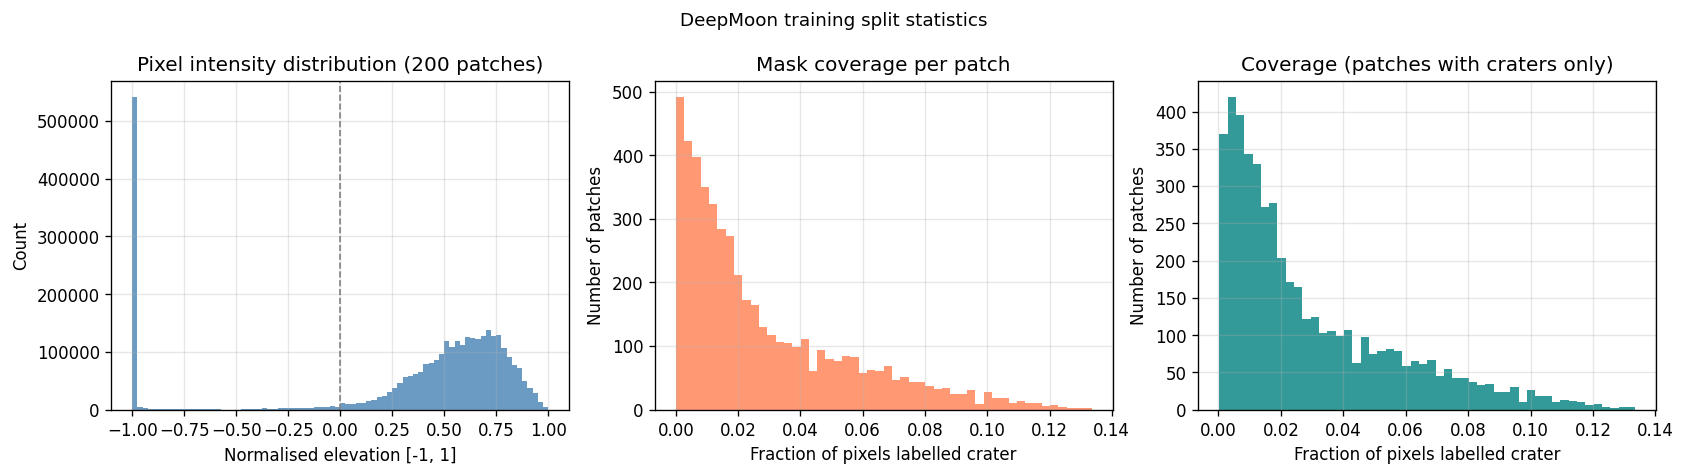

Patches with zero coverage (no crater pixels): 160
Patches with any crater:  4840
Mean coverage (all):      0.0284
Mean coverage (>0 only):  0.0293
Max coverage:             0.1335


In [5]:
coverages    = train_masks.mean(axis=(1, 2))  # fraction of pixels that are crater
sample_pixels = train_images[:200].ravel()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(sample_pixels, bins=80, color='steelblue', alpha=0.8)
axes[0].set_title('Pixel intensity distribution (200 patches)')
axes[0].set_xlabel('Normalised elevation [-1, 1]')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='gray', ls='--', lw=1)

axes[1].hist(coverages, bins=50, color='coral', alpha=0.8)
axes[1].set_title('Mask coverage per patch')
axes[1].set_xlabel('Fraction of pixels labelled crater')
axes[1].set_ylabel('Number of patches')

axes[2].hist(coverages[coverages > 0], bins=50, color='teal', alpha=0.8)
axes[2].set_title('Coverage (patches with craters only)')
axes[2].set_xlabel('Fraction of pixels labelled crater')
axes[2].set_ylabel('Number of patches')

plt.suptitle('DeepMoon training split statistics', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig6_dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Patches with zero coverage (no crater pixels): {(coverages == 0).sum()}')
print(f'Patches with any crater:  {(coverages > 0).sum()}')
print(f'Mean coverage (all):      {coverages.mean():.4f}')
print(f'Mean coverage (>0 only):  {coverages[coverages > 0].mean():.4f}')
print(f'Max coverage:             {coverages.max():.4f}')

## 4. Visualise real DEM patches with their ground-truth masks

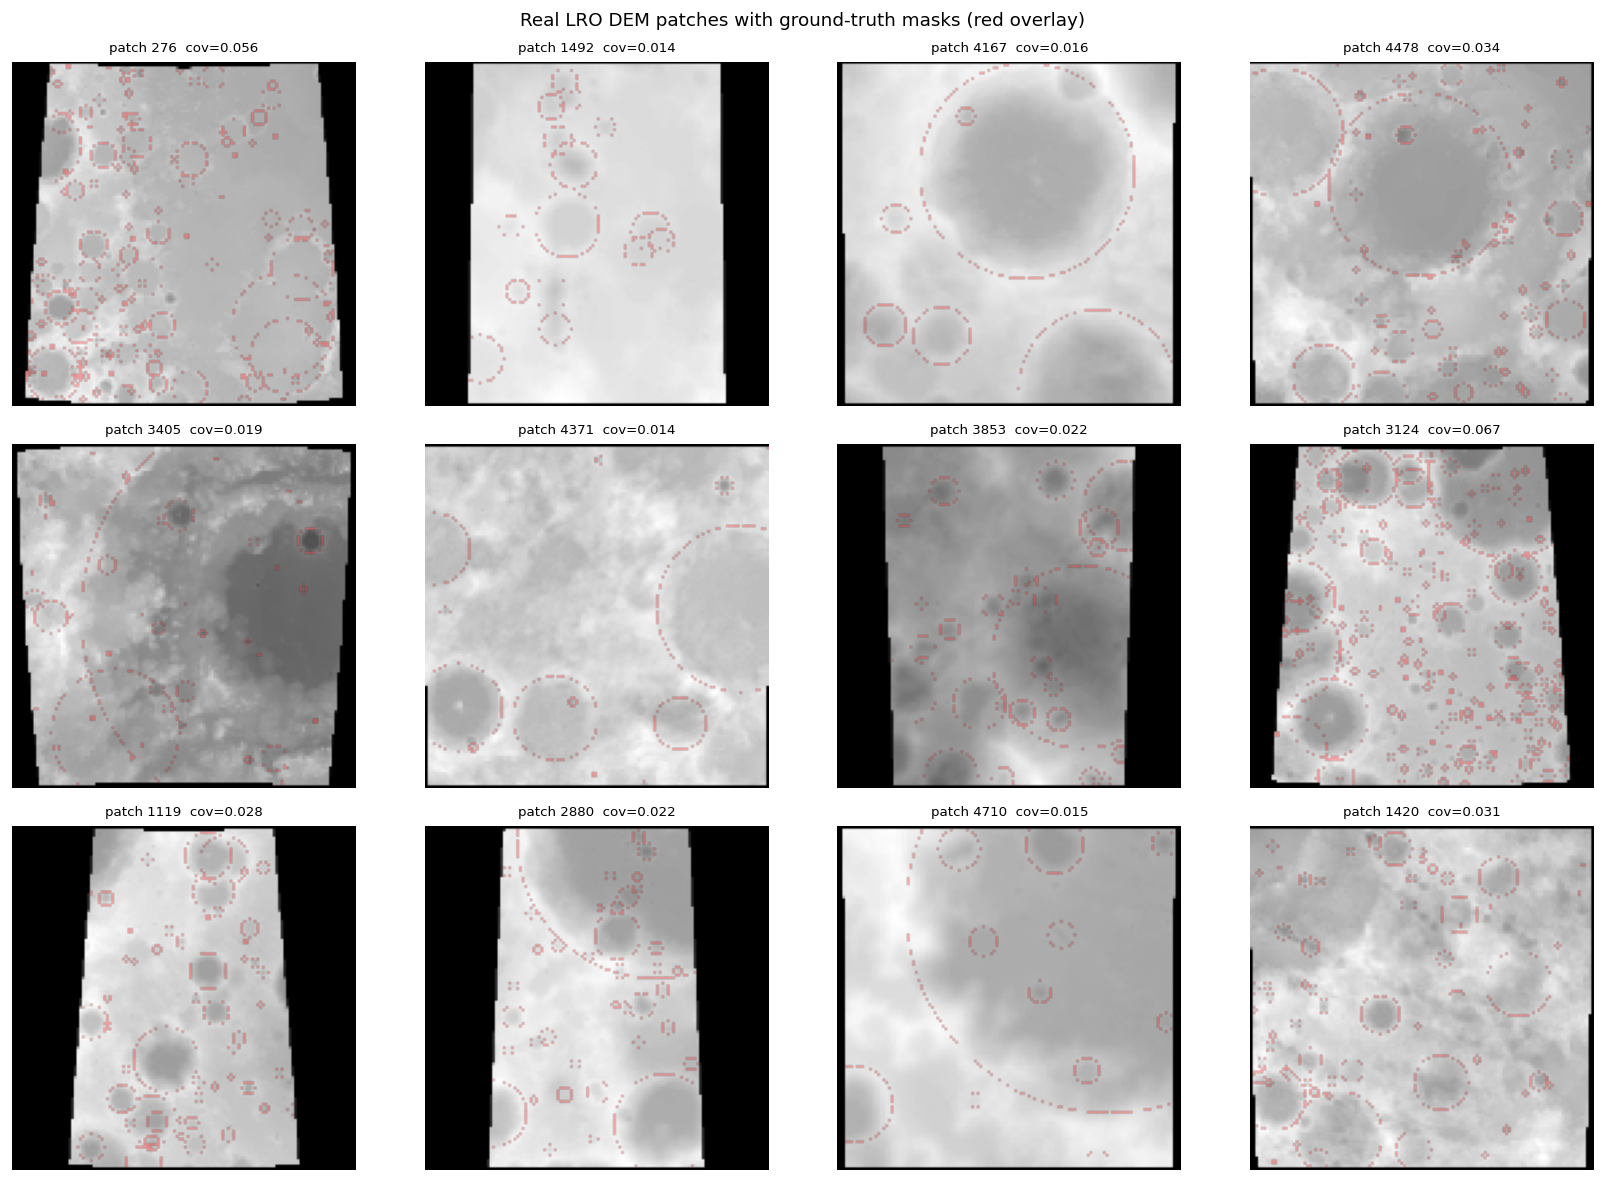

Saved: fig7_real_dem_patches.png


In [6]:
# Select patches that have craters
has_crater = np.where(coverages > 0.01)[0]
rng = np.random.default_rng(seed=7)
sample_idx = rng.choice(has_crater, size=min(12, len(has_crater)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(train_images[idx], cmap='gray', vmin=-1, vmax=1)
    # Overlay mask in red
    mask_rgb = np.zeros((*train_masks[idx].shape, 4))
    mask_rgb[train_masks[idx] > 0] = [1, 0.2, 0.2, 0.4]
    ax.imshow(mask_rgb)
    ax.set_title(f'patch {idx}  cov={coverages[idx]:.3f}', fontsize=8)
    ax.axis('off')

plt.suptitle('Real LRO DEM patches with ground-truth masks (red overlay)', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig7_real_dem_patches.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_real_dem_patches.png')

## 5. DEM patch and mask side by side

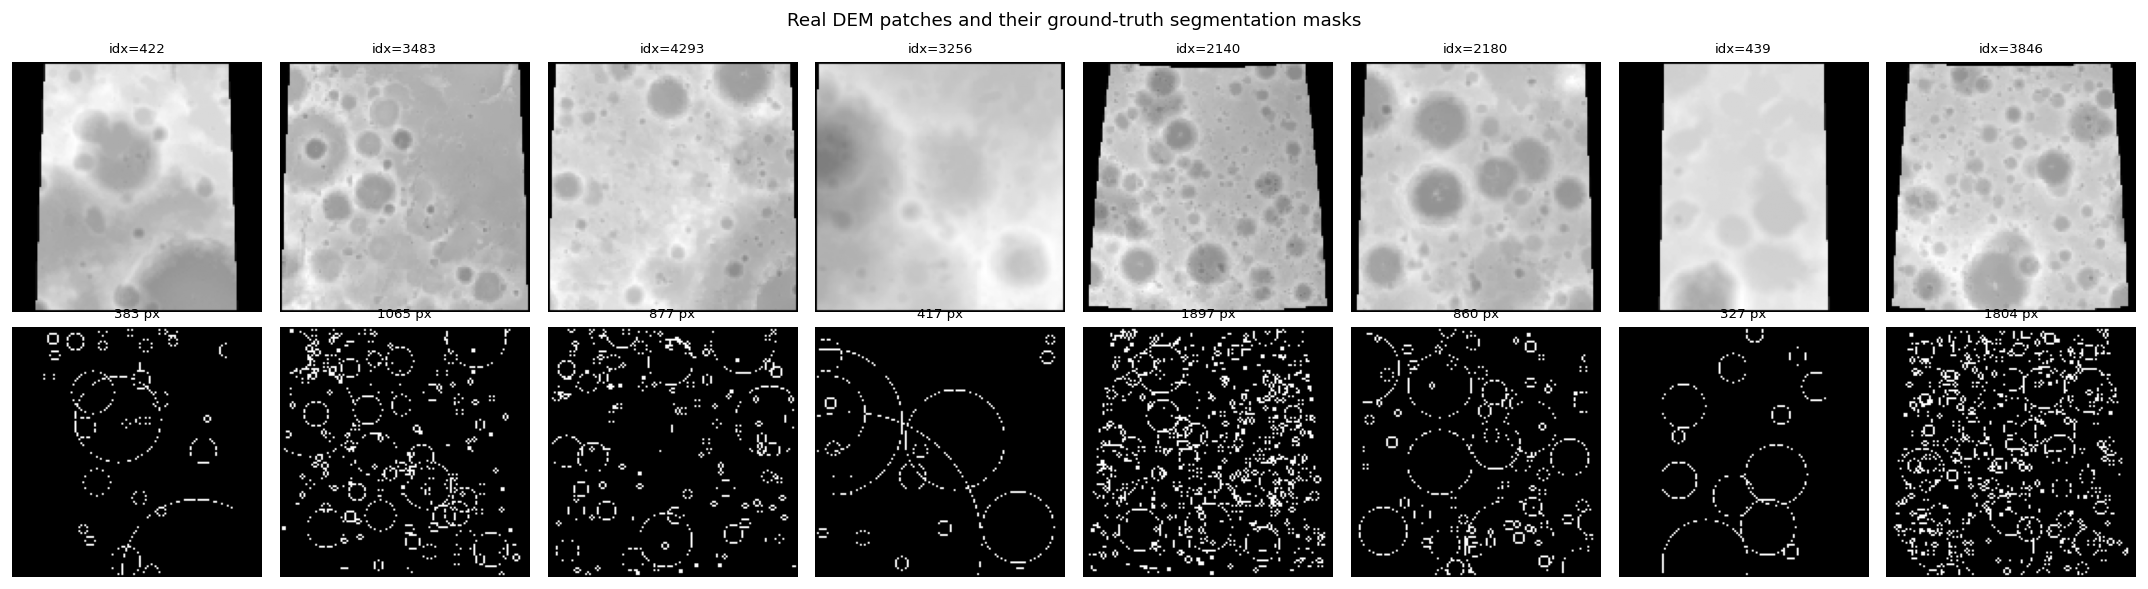

Saved: fig8_real_masks.png


In [7]:
rng = np.random.default_rng(seed=42)
sample_8 = rng.choice(has_crater, size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for col, idx in enumerate(sample_8):
    axes[0, col].imshow(train_images[idx], cmap='gray', vmin=-1, vmax=1)
    axes[0, col].set_title(f'idx={idx}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(train_masks[idx], cmap='binary_r')
    axes[1, col].set_title(f'{int(train_masks[idx].sum())} px', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('DEM', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)

plt.suptitle('Real DEM patches and their ground-truth segmentation masks', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig8_real_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_real_masks.png')

## 6. Real vs NFW synthetic: the key comparison

This is the central figure of the project. Real LRO DEM patches placed
next to NFW-synthetic craters with matched approximate size, with
cross-sections overlaid on the same axes.

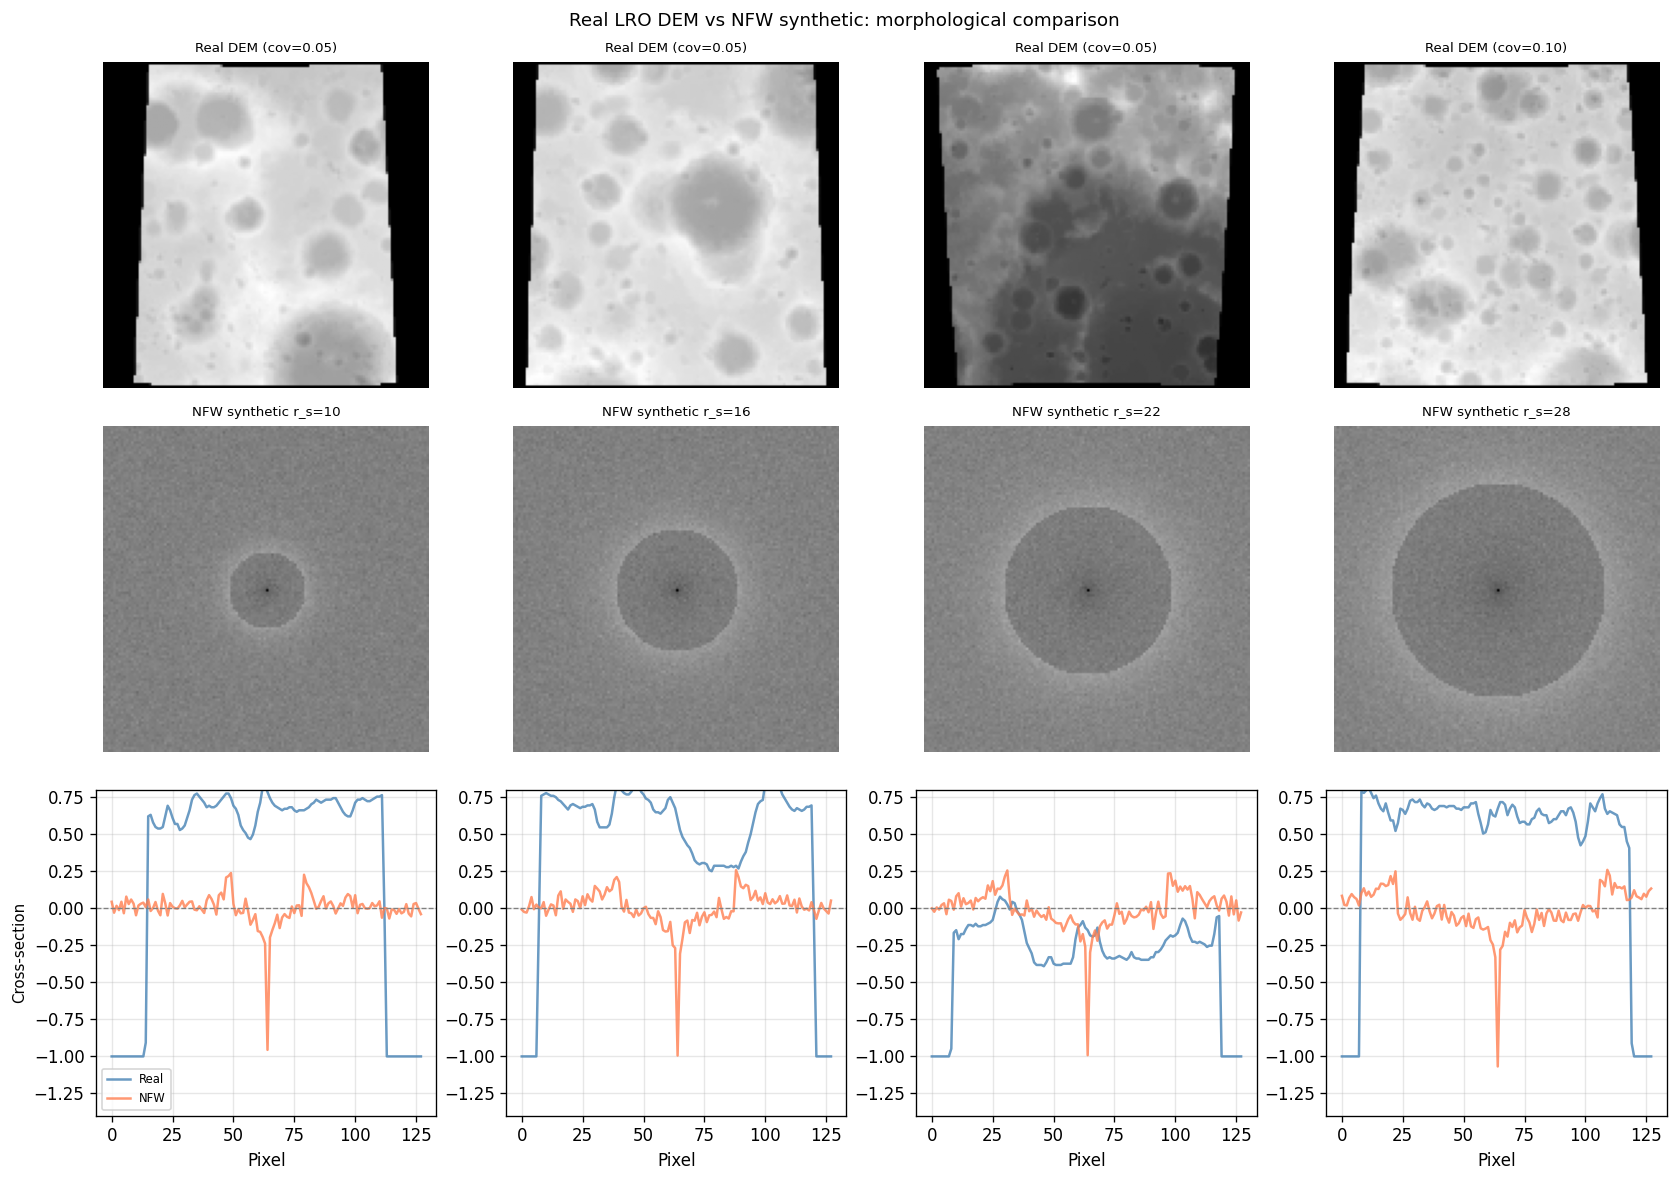

Saved: fig9_real_vs_synthetic.png


In [8]:
def nfw_projected_F(x):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    F = np.zeros_like(x)
    m1 = x < 1.0
    xm = x[m1]
    F[m1] = (1.0/(xm**2-1.0))*(1.0 - np.arccosh(1.0/xm)/np.sqrt(1.0-xm**2))
    F[np.abs(x-1.0) < 1e-6] = 1.0/3.0
    m3 = x > 1.0
    xm = x[m3]
    F[m3] = (1.0/(xm**2-1.0))*(1.0 - np.arctan(np.sqrt(xm**2-1.0))/np.sqrt(xm**2-1.0))
    return F

def make_synthetic_crater(size=128, r_s=20.0, rho_s=1.0,
                          r_rim_factor=1.5, t0_ejecta=0.25,
                          alpha_ejecta=3.2, noise_std=0.03,
                          center_offset=(0,0), rng=None):
    if rng is None:
        rng = np.random.default_rng()
    cx = size//2 + center_offset[1]
    cy = size//2 + center_offset[0]
    yg, xg = np.ogrid[:size, :size]
    R = np.sqrt((xg-cx)**2 + (yg-cy)**2) + 1e-3
    sigma = 2.0*rho_s*r_s*nfw_projected_F(R/r_s)
    bowl = -sigma/sigma.max()
    r_rim = r_rim_factor*r_s
    rim = np.zeros_like(bowl)
    outside = R > r_rim
    rim[outside] = t0_ejecta*(R[outside]/r_rim)**(-alpha_ejecta)
    dem = bowl + rim
    dem = dem/np.abs(dem).max()
    dem += rng.normal(0, noise_std, dem.shape)
    return dem.astype(np.float32)


# Pick 4 patches where crater covers a moderate area
good_idx = np.where((coverages > 0.03) & (coverages < 0.25))[0]
rng = np.random.default_rng(seed=15)
pick4 = rng.choice(good_idx, size=4, replace=False)
r_s_values = [10, 16, 22, 28]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col in range(4):
    idx = pick4[col]
    real = train_images[idx]
    synth = make_synthetic_crater(size=128, r_s=r_s_values[col],
                                  noise_std=0.04,
                                  rng=np.random.default_rng(seed=col))

    axes[0, col].imshow(real, cmap='gray', vmin=-1, vmax=1)
    axes[0, col].set_title(f'Real DEM (cov={coverages[idx]:.2f})', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(synth, cmap='gray', vmin=-1, vmax=1)
    axes[1, col].set_title(f'NFW synthetic r_s={r_s_values[col]}', fontsize=8)
    axes[1, col].axis('off')

    axes[2, col].plot(real[64, :],  'steelblue', lw=1.5, label='Real', alpha=0.8)
    axes[2, col].plot(synth[64, :], 'coral',     lw=1.5, label='NFW',  alpha=0.8)
    axes[2, col].axhline(0, color='gray', ls='--', lw=0.8)
    axes[2, col].set_ylim(-1.4, 0.8)
    axes[2, col].set_xlabel('Pixel')
    if col == 0:
        axes[2, col].set_ylabel('Elevation')
        axes[2, col].legend(fontsize=7)

axes[0, 0].set_ylabel('Real DEM', fontsize=9)
axes[1, 0].set_ylabel('NFW Synthetic', fontsize=9)
axes[2, 0].set_ylabel('Cross-section', fontsize=9)

plt.suptitle('Real LRO DEM vs NFW synthetic: morphological comparison', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig9_real_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig9_real_vs_synthetic.png')

## 7. Radial elevation profile: real mean vs NFW theoretical

Extract the radial profile from many real DEM patches centred on the
crater mask centroid, average them, and compare to the NFW curve.
This is the quantitative validation of the morphological analogy.

Extracting radial profiles from training patches...
Extracted 1858 valid profiles


/tmp/ipykernel_4995/3734181994.py:37: RuntimeWarning: Mean of empty slice
  mean_prof = np.nanmean(stack, axis=0)
/mnt/c/Users/Myriam/darknav/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


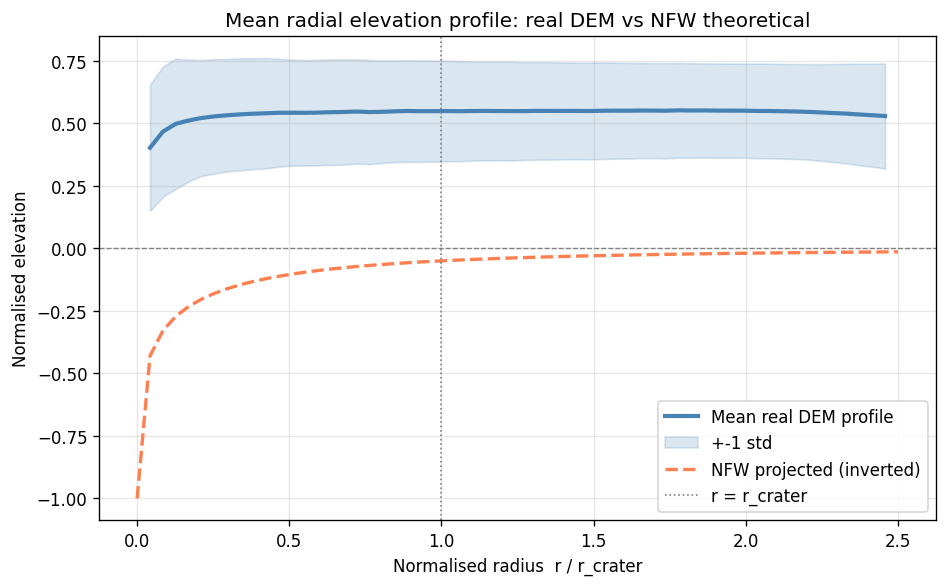

Saved: fig11_profile_comparison.png


In [9]:
def radial_profile_from_mask(image, mask, max_r_factor=2.5, n_bins=50):
    """Radial elevation profile centred on mask centroid, normalised by mask radius."""
    if mask.sum() == 0:
        return None, None
    yg, xg = np.mgrid[:image.shape[0], :image.shape[1]]
    cy = (yg * mask).sum() / mask.sum()
    cx = (xg * mask).sum() / mask.sum()
    r_eff = np.sqrt(mask.sum() / np.pi)  # effective radius in pixels
    if r_eff < 3:
        return None, None
    R = np.sqrt((xg - cx)**2 + (yg - cy)**2)
    max_r = max_r_factor * r_eff
    bins = np.linspace(0, max_r, n_bins + 1)
    profile = np.zeros(n_bins)
    for b in range(n_bins):
        pix = (R >= bins[b]) & (R < bins[b+1])
        if pix.sum() > 0:
            profile[b] = image[pix].mean()
    r_norm = (bins[:-1] + np.diff(bins)/2) / r_eff
    return r_norm, profile


print('Extracting radial profiles from training patches...')
all_profiles = []
r_common = np.linspace(0, 2.5, 60)

for i in range(min(2000, len(train_images))):
    r_norm, prof = radial_profile_from_mask(train_images[i], train_masks[i])
    if r_norm is not None and len(r_norm) > 5:
        f_interp = interp1d(r_norm, prof, bounds_error=False, fill_value=np.nan)
        all_profiles.append(f_interp(r_common))

print(f'Extracted {len(all_profiles)} valid profiles')

if len(all_profiles) > 10:
    stack = np.array(all_profiles)
    mean_prof = np.nanmean(stack, axis=0)
    std_prof  = np.nanstd(stack, axis=0)

    # NFW theoretical profile
    sigma_nfw = 2.0 * 1.0 * 1.0 * nfw_projected_F(r_common + 1e-3)
    nfw_prof  = -sigma_nfw / sigma_nfw.max()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(r_common, mean_prof, 'steelblue', lw=2.5, label='Mean real DEM profile')
    ax.fill_between(r_common,
                    mean_prof - std_prof,
                    mean_prof + std_prof,
                    alpha=0.2, color='steelblue', label='+-1 std')
    ax.plot(r_common, nfw_prof, 'coral', lw=2, ls='--', label='NFW projected (inverted)')
    ax.axvline(1.0, color='gray', ls=':', lw=1, label='r = r_crater')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('Normalised radius  r / r_crater')
    ax.set_ylabel('Normalised elevation')
    ax.set_title('Mean radial elevation profile: real DEM vs NFW theoretical')
    ax.legend()
    plt.tight_layout()
    plt.savefig(DOCS_DIR / 'fig11_profile_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig11_profile_comparison.png')

## 8. Mask coverage filter and quality selection

Filter out patches that are not useful for training:
- Zero coverage: no crater pixels at all
- Coverage below 0.5 percent: crater too small after downsampling
- Coverage above 60 percent: almost entirely crater, likely a labelling artefact

Total loaded: 5000
Zero coverage: 160
Below min (0.005): 855
Above max (0.6): 0
Valid patches: 4145


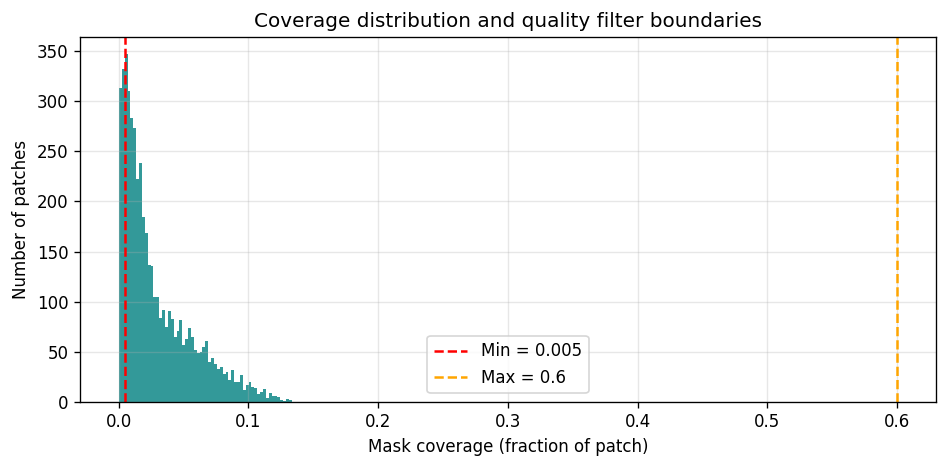

Saved: fig12_coverage_distribution.png
Saved valid indices: 4145 patches -> data/train_valid_indices.npy


In [10]:
MIN_COV = 0.005
MAX_COV = 0.60

valid = (coverages >= MIN_COV) & (coverages <= MAX_COV)
valid_indices = np.where(valid)[0]

print(f'Total loaded: {len(coverages)}')
print(f'Zero coverage: {(coverages == 0).sum()}')
print(f'Below min ({MIN_COV}): {(coverages < MIN_COV).sum()}')
print(f'Above max ({MAX_COV}): {(coverages > MAX_COV).sum()}')
print(f'Valid patches: {valid.sum()}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(coverages[coverages > 0], bins=60, color='teal', alpha=0.8)
ax.axvline(MIN_COV, color='red',    ls='--', lw=1.5, label=f'Min = {MIN_COV}')
ax.axvline(MAX_COV, color='orange', ls='--', lw=1.5, label=f'Max = {MAX_COV}')
ax.set_xlabel('Mask coverage (fraction of patch)')
ax.set_ylabel('Number of patches')
ax.set_title('Coverage distribution and quality filter boundaries')
ax.legend()
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig12_coverage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig12_coverage_distribution.png')

np.save(DATA_DIR / 'train_valid_indices.npy', valid_indices)
print(f'Saved valid indices: {valid_indices.shape[0]} patches -> data/train_valid_indices.npy')

## 9. Threshold calibration for the synthetic mask generator

In the NFW synthetic generator, binary masks are created by thresholding
the DEM at a fixed value. We calibrate this threshold so that the
resulting mask radius matches r_s.

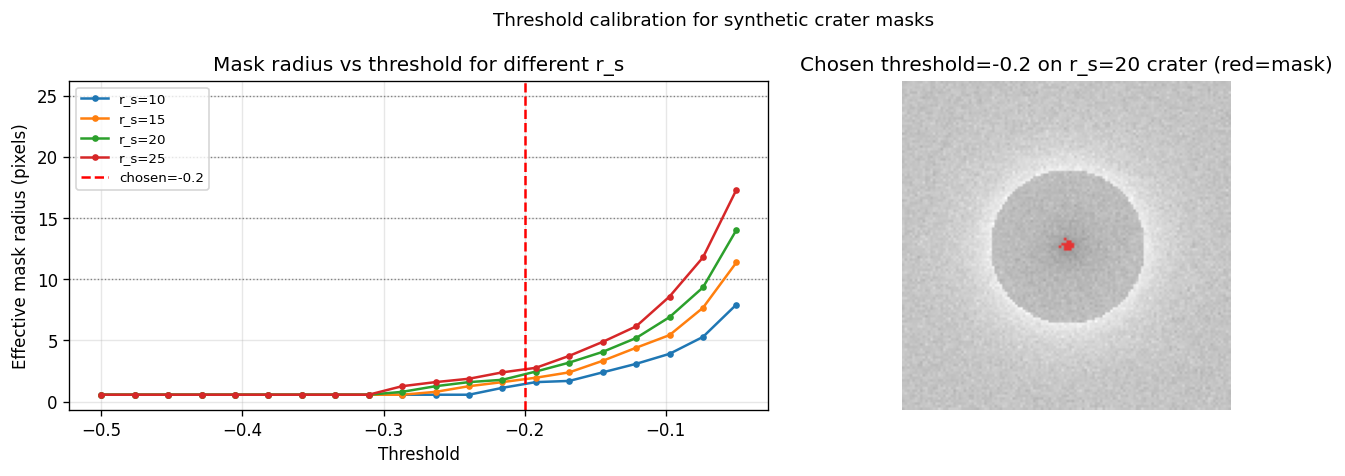

Chosen threshold: -0.2


In [11]:
def mask_effective_radius(mask):
    labeled, n = scipy_label(mask)
    if n == 0:
        return 0.0
    sizes = [(labeled == i).sum() for i in range(1, n+1)]
    return np.sqrt(max(sizes) / np.pi)


thresholds = np.linspace(-0.05, -0.50, 20)
r_s_test   = [10, 15, 20, 25]
results    = {r_s: [] for r_s in r_s_test}

for r_s in r_s_test:
    crater = make_synthetic_crater(size=128, r_s=r_s, noise_std=0.01,
                                   rng=np.random.default_rng(seed=r_s))
    for thr in thresholds:
        m = (crater < thr).astype(np.uint8)
        results[r_s].append(mask_effective_radius(m))

chosen = -0.20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r_s, radii in results.items():
    axes[0].plot(thresholds, radii, marker='o', ms=3, label=f'r_s={r_s}')
    axes[0].axhline(r_s, color='gray', ls=':', lw=0.8)
axes[0].axvline(chosen, color='red', ls='--', lw=1.5, label=f'chosen={chosen}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Effective mask radius (pixels)')
axes[0].set_title('Mask radius vs threshold for different r_s')
axes[0].legend(fontsize=8)

crater_demo = make_synthetic_crater(size=128, r_s=20, noise_std=0.03,
                                    rng=np.random.default_rng(5))
mask_demo = (crater_demo < chosen).astype(np.uint8)
overlay = np.stack([crater_demo]*3, axis=-1)
overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min())
overlay[mask_demo == 1] = [0.9, 0.2, 0.2]

axes[1].imshow(overlay)
axes[1].set_title(f'Chosen threshold={chosen} on r_s=20 crater (red=mask)')
axes[1].axis('off')

plt.suptitle('Threshold calibration for synthetic crater masks', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig10_threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chosen threshold: {chosen}')

## 10. Summary and decisions for Day 3

In [12]:
print('Dataset structure (actual, from inspection):')
print('  train_images.hdf5 -> input_images (N,256,256) + target_masks (N,256,256)')
print('  train_craters.hdf5 -> crater catalogue per patch')
print('  No CSV files. Masks are precomputed and stored in the images HDF5.')
print()
print('Decisions for Day 3:')
print()
print('1. Data loading: use input_images and target_masks from the same HDF5.')
print('   Downsample with zoom(order=1) for images, zoom(order=0) for masks.')
print()
print('2. Quality filter: coverage in [0.005, 0.60].')
print(f'   Valid training patches: {valid_indices.shape[0]}')
print()
print('3. Synthetic mask threshold: -0.20')
print()
print('4. r_s sampling range for synthetic generator: U(8, 30) pixels')
print()
print('5. Training set plan: 1500 real filtered patches + 1500 synthetic NFW patches')
print()
print('Figures generated:')
for name in ['fig6_dataset_statistics', 'fig7_real_dem_patches', 'fig8_real_masks',
             'fig9_real_vs_synthetic', 'fig10_threshold_calibration',
             'fig11_profile_comparison', 'fig12_coverage_distribution']:
    ok = 'OK' if (DOCS_DIR / f'{name}.png').exists() else 'MISSING'
    print(f'  {ok}: docs/{name}.png')

Dataset structure (actual, from inspection):
  train_images.hdf5 -> input_images (N,256,256) + target_masks (N,256,256)
  train_craters.hdf5 -> crater catalogue per patch
  No CSV files. Masks are precomputed and stored in the images HDF5.

Decisions for Day 3:

1. Data loading: use input_images and target_masks from the same HDF5.
   Downsample with zoom(order=1) for images, zoom(order=0) for masks.

2. Quality filter: coverage in [0.005, 0.60].
   Valid training patches: 4145

3. Synthetic mask threshold: -0.20

4. r_s sampling range for synthetic generator: U(8, 30) pixels

5. Training set plan: 1500 real filtered patches + 1500 synthetic NFW patches

Figures generated:
  OK: docs/fig6_dataset_statistics.png
  OK: docs/fig7_real_dem_patches.png
  OK: docs/fig8_real_masks.png
  OK: docs/fig9_real_vs_synthetic.png
  OK: docs/fig10_threshold_calibration.png
  OK: docs/fig11_profile_comparison.png
  OK: docs/fig12_coverage_distribution.png
